# Import the datasets using the web scraping 

In [4]:
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import time

driver = webdriver.Chrome()
driver.get("https://www.iplt20.com/stats/2026")
time.sleep(5)
all_data=driver.find_element(By.XPATH,"//div[2]//div[2]//div//div[3]//div//div[1]//table//tbody").text


'POS Player'

In [5]:
all_data[:60]

'POS Player Runs Mat Inns NO HS Avg BF SR 100 50 4s 6s\n1\nVaib'

## Data Cleanings and reshapings 

In [10]:
columns=all_data.split("\n")[0]
columns=columns.split()
columns

['POS',
 'Player',
 'Runs',
 'Mat',
 'Inns',
 'NO',
 'HS',
 'Avg',
 'BF',
 'SR',
 '100',
 '50',
 '4s',
 '6s']

In [14]:
all_data.split("\n")[1:][:10]

['1',
 'Vaibhav Sooryavanshi',
 'RR',
 '776 16 16 0 103 48.50 327 237.30 1 5 63 72',
 '2',
 'Shubman Gill',
 'GT',
 '732 16 16 0 104 45.75 449 163.02 1 6 74 33',
 '3',
 'Sai Sudharsan']

### Convert into the Nupy array 

In [19]:
import numpy as np
arr_data=np.array(all_data.split("\n")[1:])
arr_data[:15]

array(['1', 'Vaibhav Sooryavanshi', 'RR',
       '776 16 16 0 103 48.50 327 237.30 1 5 63 72', '2', 'Shubman Gill',
       'GT', '732 16 16 0 104 45.75 449 163.02 1 6 74 33', '3',
       'Sai Sudharsan', 'GT',
       '722 17 17 1 100 45.13 457 157.98 1 8 75 30', '4', 'Virat Kohli',
       'RCB'], dtype='<U43')

In [28]:
### 1 player have the 4 ietms of data 

arr_data=arr_data.reshape(int(arr_data.shape[0]/4),4)
arr_data[:5]

array([['1', 'Vaibhav Sooryavanshi', 'RR',
        '776 16 16 0 103 48.50 327 237.30 1 5 63 72'],
       ['2', 'Shubman Gill', 'GT',
        '732 16 16 0 104 45.75 449 163.02 1 6 74 33'],
       ['3', 'Sai Sudharsan', 'GT',
        '722 17 17 1 100 45.13 457 157.98 1 8 75 30'],
       ['4', 'Virat Kohli', 'RCB',
        '675 16 16 4 105* 56.25 407 165.84 1 5 73 25'],
       ['5', 'Heinrich Klaasen', 'SRH',
        '624 15 15 2 69 48.00 390 160.00 0 6 48 31']], dtype='<U43')

## Convert this into the pandas DataFrame 

In [31]:
import pandas as pd

df=pd.DataFrame(arr_data)
df

,0,1,2,3
0,1,Vaibhav Sooryavanshi,RR,776 16 16 0 103 48.50 327 237.30 1 5 63 72
1,2,Shubman Gill,GT,732 16 16 0 104 45.75 449 163.02 1 6 74 33
2,3,Sai Sudharsan,GT,722 17 17 1 100 45.13 457 157.98 1 8 75 30
3,4,Virat Kohli,RCB,675 16 16 4 105* 56.25 407 165.84 1 5 73 25
4,5,Heinrich Klaasen,SRH,624 15 15 2 69 48.00 390 160.00 0 6 48 31
...,...,...,...,...
162,163,T Natarajan,DC,1 10 1 1 1* - 2 50.00 0 0 0 0
163,164,Vaibhav Arora,KKR,1 11 2 2 1* - 3 33.33 0 0 0 0
164,165,Sushant Mishra,RR,1 2 1 1 1* - 3 33.33 0 0 0 0
165,166,Ashok Sharma,GT,1 6 2 2 1* - 4 25.00 0 0 0 0


## Clean the data 

In [35]:
other_info=df[3].str.split(" ",expand=True)
other_info

,0,1,2,3,4,5,6,7,8,9,10,11
0,776,16,16,0,103,48.50,327,237.30,1,5,63,72
1,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,722,17,17,1,100,45.13,457,157.98,1,8,75,30
3,675,16,16,4,105*,56.25,407,165.84,1,5,73,25
4,624,15,15,2,69,48.00,390,160.00,0,6,48,31
...,...,...,...,...,...,...,...,...,...,...,...,...
162,1,10,1,1,1*,-,2,50.00,0,0,0,0
163,1,11,2,2,1*,-,3,33.33,0,0,0,0
164,1,2,1,1,1*,-,3,33.33,0,0,0,0
165,1,6,2,2,1*,-,4,25.00,0,0,0,0


In [36]:
columns

['POS',
 'Player',
 'Runs',
 'Mat',
 'Inns',
 'NO',
 'HS',
 'Avg',
 'BF',
 'SR',
 '100',
 '50',
 '4s',
 '6s']

In [37]:
other_info.columns=columns[2:]
other_info.head()

,Runs,Mat,Inns,NO,HS,Avg,BF,SR,100,50,4s,6s
0,776,16,16,0,103,48.50,327,237.30,1,5,63,72
1,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,722,17,17,1,100,45.13,457,157.98,1,8,75,30
3,675,16,16,4,105*,56.25,407,165.84,1,5,73,25
4,624,15,15,2,69,48.00,390,160.00,0,6,48,31


## Combine with the Originla dataframes 

In [40]:
df=df[[0,1,2]]
df

,0,1,2
0,1,Vaibhav Sooryavanshi,RR
1,2,Shubman Gill,GT
2,3,Sai Sudharsan,GT
3,4,Virat Kohli,RCB
4,5,Heinrich Klaasen,SRH
...,...,...,...
162,163,T Natarajan,DC
163,164,Vaibhav Arora,KKR
164,165,Sushant Mishra,RR
165,166,Ashok Sharma,GT


In [41]:
df.columns=["player_pos","Pname","Team"]
df

,player_pos,Pname,Team
0,1,Vaibhav Sooryavanshi,RR
1,2,Shubman Gill,GT
2,3,Sai Sudharsan,GT
3,4,Virat Kohli,RCB
4,5,Heinrich Klaasen,SRH
...,...,...,...
162,163,T Natarajan,DC
163,164,Vaibhav Arora,KKR
164,165,Sushant Mishra,RR
165,166,Ashok Sharma,GT


## Combine with the other informations 

In [44]:
all_final=pd.concat([df,other_info],axis=1)
all_final

,player_pos,Pname,Team,Runs,Mat,Inns,NO,HS,Avg,BF,SR,100,50,4s,6s
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.50,327,237.30,1,5,63,72
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,157.98,1,8,75,30
3,4,Virat Kohli,RCB,675,16,16,4,105*,56.25,407,165.84,1,5,73,25
4,5,Heinrich Klaasen,SRH,624,15,15,2,69,48.00,390,160.00,0,6,48,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,163,T Natarajan,DC,1,10,1,1,1*,-,2,50.00,0,0,0,0
163,164,Vaibhav Arora,KKR,1,11,2,2,1*,-,3,33.33,0,0,0,0
164,165,Sushant Mishra,RR,1,2,1,1,1*,-,3,33.33,0,0,0,0
165,166,Ashok Sharma,GT,1,6,2,2,1*,-,4,25.00,0,0,0,0


## clean the dataas 

In [47]:
all_final["HS"]=all_final["HS"].str.replace("*","")
all_final["Avg"]=all_final["Avg"].str.replace("-","0")

In [48]:
numerical_cols=all_final.columns[3:]
numerical_cols

Index(['Runs', 'Mat', 'Inns', 'NO', 'HS', 'Avg', 'BF', 'SR', '100', '50', '4s',
       '6s'],
      dtype='object')

## changeb the data types of all the columns into the numeric 

In [50]:
for col in numerical_cols:
    all_final[col]=pd.to_numeric(all_final[col], errors="raise")

In [51]:
all_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   player_pos  167 non-null    object 
 1   Pname       167 non-null    object 
 2   Team        167 non-null    object 
 3   Runs        167 non-null    int64  
 4   Mat         167 non-null    int64  
 5   Inns        167 non-null    int64  
 6   NO          167 non-null    int64  
 7   HS          167 non-null    int64  
 8   Avg         167 non-null    float64
 9   BF          167 non-null    int64  
 10  SR          167 non-null    float64
 11  100         167 non-null    int64  
 12  50          167 non-null    int64  
 13  4s          167 non-null    int64  
 14  6s          167 non-null    int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 19.7+ KB


In [52]:
all_final.to_csv("extracted_datasets.csv",index=False)

## Extractingt the features 

In [55]:
all_final.head(3)

,player_pos,Pname,Team,Runs,Mat,Inns,NO,HS,Avg,BF,SR,100,50,4s,6s
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.50,327,237.30,1,5,63,72
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,157.98,1,8,75,30


## Boundary Runs

In [57]:
all_final["boundary_runs"] = (
    all_final["4s"] * 4 +
    all_final["6s"] * 6
)

## Boundary Dependency

In [58]:
all_final["boundary_dependency"] = (
    all_final["boundary_runs"] /
    all_final["Runs"]
) * 100

### Runs Per Match

In [59]:
all_final["runs_per_match"] = (
    all_final["Runs"] /
    all_final["Mat"]
)

## Six Ratio

In [60]:
all_final["six_ratio"] = (
    all_final["6s"] /
    (all_final["4s"] + 1)
)

### Batting Impact Score

In [61]:
all_final["impact_score"] = (
    all_final["Runs"]*0.4 +
    all_final["SR"]*0.3 +
    all_final["Avg"]*0.2 +
    all_final["50"]*20 +
    all_final["100"]*50
)

## Step 4: Select Clustering Features

In [62]:
features = [
    "Runs",
    "Avg",
    "SR",
    "boundary_dependency",
    "runs_per_match",
    "impact_score",
    "4s",
    "6s"
]

In [64]:
all_final[features] = all_final[features].fillna(0)

## Step 6: Standardize Data

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(all_final[features])
X_scaled.shape

(167, 8)

In [66]:
import warnings
warnings.filterwarnings("ignore")

In [68]:
X_scaled[:5]

array([[3.34851978, 1.71430193, 2.11624377, 1.20029763, 2.63625431,
        3.34289768, 2.78586667, 5.59100639],
       [3.11065546, 1.54672215, 0.5700499 , 0.40796386, 2.42550874,
        3.176678  , 3.41080709, 2.15505389],
       [3.05659538, 1.50894052, 0.46513852, 0.3694424 , 2.17419183,
        3.4562108 , 3.46761986, 1.89074985],
       [2.80251304, 2.18657222, 0.62875031, 0.3310679 , 2.15249743,
        2.85248698, 3.35399433, 1.45024312],
       [2.52680667, 1.68383288, 0.50718633, 0.14295438, 2.10747451,
        2.41483643, 1.9336752 , 1.97885119]])

## Step 7: Find Optimal K

In [69]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

## show the elbow methods 

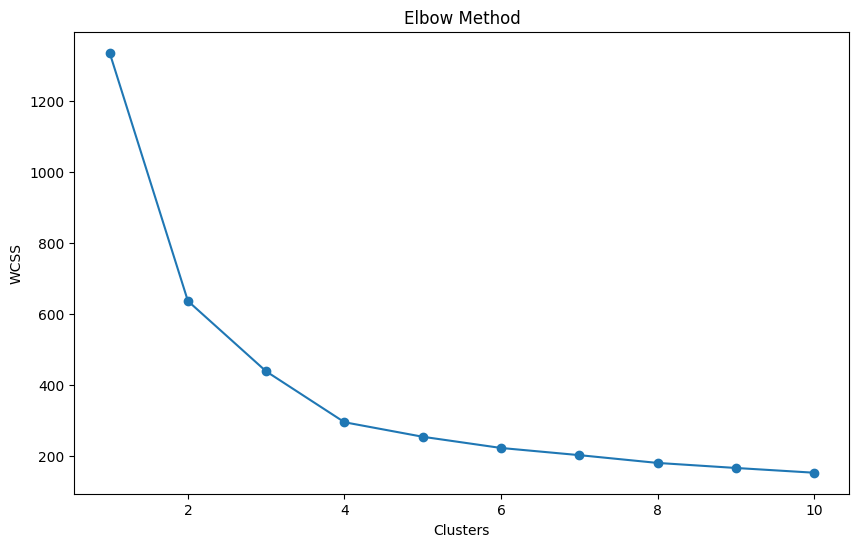

In [70]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Step 8: Silhouette Score

In [71]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, score)

2 0.45757523141105383
3 0.3890301882825199
4 0.41978078302772437
5 0.41100958032975515
6 0.3525369359255511
7 0.33810347921249123
8 0.3154086731850679
9 0.313980948349375
10 0.31015634011741927


## select the K=5 for the optimum cluster fior the pleayers

In [73]:
all_final['cluster'] = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
).fit_predict(X_scaled)

all_final['cluster'].value_counts()

cluster
2    60
0    46
4    25
3    23
1    13
Name: count, dtype: int64

## Check the clusters Profiles `

In [75]:
cluster_profile = (
    all_final.groupby('cluster')
      [['Runs','Avg','SR','4s','6s','impact_score']]
      .mean()
      .round(2)
)

cluster_profile

,Runs,Avg,SR,4s,6s,impact_score
cluster,,,,,,
0,232.46,34.00,154.33,20.30,12.11,172.17
1,35.31,12.11,209.98,2.38,2.92,82.62
2,44.12,11.50,117.40,3.67,1.92,55.50
3,532.70,41.38,175.01,49.83,31.13,385.60
4,4.00,1.52,70.10,0.04,0.00,22.93


## use the pca and implementhe 2 clusters 

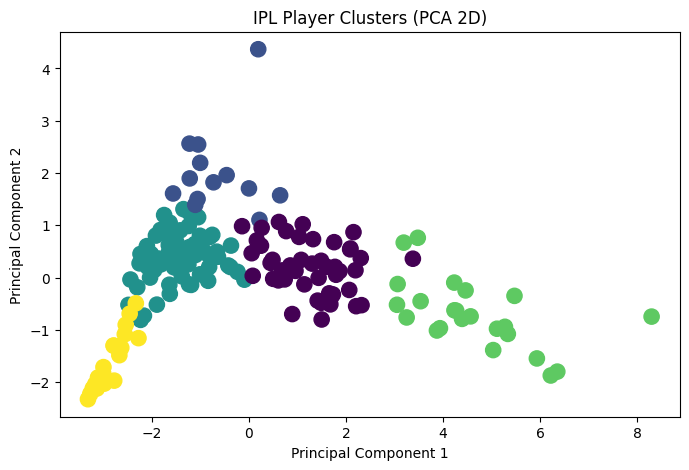

In [81]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
components_2d = pca_2d.fit_transform(X_scaled)

all_final["PC1"] = components_2d[:, 0]
all_final["PC2"] = components_2d[:, 1]

plt.figure(figsize=(8,5))
plt.scatter(all_final["PC1"], all_final["PC2"], c=all_final["cluster"], s=120)

plt.title("IPL Player Clusters (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Visualize in 3d arrays 

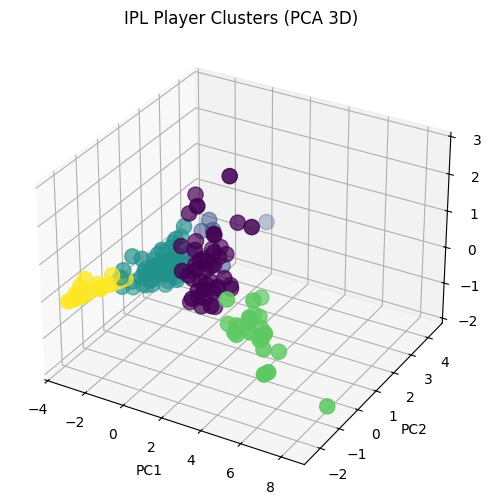

In [83]:
pca_3d = PCA(n_components=3)
components_3d = pca_3d.fit_transform(X_scaled)
all_final["PC1"] = components_3d[:, 0]
all_final["PC2"] = components_3d[:, 1]
all_final["PC3"] = components_3d[:, 2]
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_final["PC1"], all_final["PC2"], all_final["PC3"], c=all_final["cluster"], s=120)
ax.set_title("IPL Player Clusters (PCA 3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

## mapped with yhe datasets 

In [85]:
cluster_map = {
    0: "Elite Power Hitters",
    1: "High Strike Anchors",
    2: "Consistent Top Order",
    3: "Middle Order Finishers",
    4: "Low Impact / Support Batters"
}

all_final["Cluster_Label"] = all_final["cluster"].map(cluster_map)

In [86]:
all_final

,player_pos,Pname,Team,Runs,Mat,Inns,NO,HS,Avg,BF,...,boundary_runs,boundary_dependency,runs_per_match,six_ratio,impact_score,cluster,PC1,PC2,PC3,Cluster_Label
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.50,327,...,684,88.144330,48.500000,1.125000,541.290,3,8.290697,-0.743872,-1.806279,Middle Order Finishers
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,...,494,67.486339,45.750000,0.440000,520.856,3,6.349472,-1.795557,-0.671110,Middle Order Finishers
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,...,480,66.481994,42.470588,0.394737,555.220,3,6.215045,-1.869752,-0.715430,Middle Order Finishers
3,4,Virat Kohli,RCB,675,16,16,4,105,56.25,407,...,442,65.481481,42.187500,0.337838,481.002,3,5.929026,-1.543795,0.170305,Middle Order Finishers
4,5,Heinrich Klaasen,SRH,624,15,15,2,69,48.00,390,...,378,60.576923,41.600000,0.632653,427.200,3,5.029747,-1.384085,-0.022235,Middle Order Finishers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,163,T Natarajan,DC,1,10,1,1,1,0.00,2,...,0,0.000000,0.100000,0.000000,15.400,4,-3.105945,-1.912071,-0.103907,Low Impact / Support Batters
163,164,Vaibhav Arora,KKR,1,11,2,2,1,0.00,3,...,0,0.000000,0.090909,0.000000,10.399,4,-3.212977,-2.116799,-0.094786,Low Impact / Support Batters
164,165,Sushant Mishra,RR,1,2,1,1,1,0.00,3,...,0,0.000000,0.500000,0.000000,10.399,4,-3.200840,-2.119721,-0.086958,Low Impact / Support Batters
165,166,Ashok Sharma,GT,1,6,2,2,1,0.00,4,...,0,0.000000,0.166667,0.000000,7.900,4,-3.264079,-2.219676,-0.088692,Low Impact / Support Batters


In [87]:
pd.set_option("display.max_rows",None)

In [92]:
all_final.groupby("Cluster_Label")["Pname"].unique().reset_index()

,Cluster_Label,Pname
0,Consistent Top Order,"[Axar Patel, Dewald Brevis, Abdul Samad, Jites..."
1,Elite Power Hitters,"[Washington Sundar, Tilak Varma, Ruturaj Gaikw..."
2,High Strike Anchors,"[Shashank Singh, Urvil Patel, Azmatullah Omarz..."
3,Low Impact / Support Batters,"[Arshin Kulkarni, Krish Bhagat, Kuldeep Yadav,..."
4,Middle Order Finishers,"[Vaibhav Sooryavanshi, Shubman Gill, Sai Sudha..."


## all Middle Over Finishers 

In [94]:
all_final[all_final["Cluster_Label"]=="Middle Order Finishers"]["Pname"].tolist()

['Vaibhav Sooryavanshi',
 'Shubman Gill',
 'Sai Sudharsan',
 'Virat Kohli',
 'Heinrich Klaasen',
 'Ishan Kishan',
 'K L Rahul',
 'Abhishek Sharma',
 'Mitchell Marsh',
 'Jos Buttler',
 'Dhruv Jurel',
 'Prabhsimran Singh',
 'Rajat Patidar',
 'Shreyas Iyer',
 'Cooper Connolly',
 'Sanju Samson',
 'Devdutt Padikkal',
 'Ryan Rickelton',
 'Yashasvi Jaiswal',
 'Angkrish Raghuvanshi',
 'Travis Head',
 'Priyansh Arya',
 'Finn Allen']

## 	Low Impact / Support Batters

In [95]:
all_final[all_final["Cluster_Label"]=="Low Impact / Support Batters"]["Pname"].tolist()

['Arshin Kulkarni',
 'Krish Bhagat',
 'Kuldeep Yadav',
 'Lhuan-dre Pretorius',
 'Eshan Malinga',
 'David Payne',
 'Akeal Hosein',
 'Arjun Tendulkar',
 'Jaydev Unadkat',
 'Lungisani Ngidi',
 'Rasikh Dar',
 'Praful Hinge',
 'Mukesh Choudhary',
 'Adam Milne',
 'AM Ghazanfar',
 'Vyshak Vijaykumar',
 'Brijesh Sharma',
 'Danish Malewar',
 'Digvesh Singh',
 'Arshdeep Singh',
 'T Natarajan',
 'Vaibhav Arora',
 'Sushant Mishra',
 'Ashok Sharma',
 'Ashwani Kumar']

## High Strike Anchors

In [96]:
all_final[all_final["Cluster_Label"]=="High Strike Anchors"]["Pname"].tolist()

['Shashank Singh',
 'Urvil Patel',
 'Azmatullah Omarzai',
 'Xavier Bartlett',
 'Tushar Deshpande',
 'Mohd Arshad Khan',
 'Madhav Tiwari',
 'Vishnu Vinod',
 'Auqib Nabi',
 'Trent Boult',
 'Harpreet Brar',
 'Saurabh Dubey',
 'Ravi Singh']

## Elite Power Hitters

In [97]:
all_final[all_final["Cluster_Label"]=="Elite Power Hitters"]["Pname"].tolist()

['Washington Sundar',
 'Tilak Varma',
 'Ruturaj Gaikwad',
 'Ajinkya Rahane',
 'Cameron Green',
 'Naman Dhir',
 'Donovan Ferreira',
 'Rishabh Pant',
 'Riyan Parag',
 'Tim David',
 'Nitish Kumar Reddy',
 'Rinku Singh',
 'Kartik Sharma',
 'Rohit Sharma',
 'Pathum Nissanka',
 'Tristan Stubbs',
 'Shivam Dube',
 'Surya Kumar Yadav',
 'Josh Inglis',
 'Ravindra Jadeja',
 'Sameer Rizvi',
 'Nicholas Pooran',
 'Aiden Markram',
 'Krunal Pandya',
 'Nitish Rana',
 'Marcus Stoinis',
 'Ayush Badoni',
 'David Miller',
 'Venkatesh Iyer',
 'Hardik Pandya',
 'Phil Salt',
 'Ayush Mhatre',
 'Rahul Tewatia',
 'Rovman Powell',
 'Ashutosh Sharma',
 'Mukul Choudhary',
 'Sarfaraz Khan',
 'Suryansh Shedge',
 'Salil Arora',
 'Will Jacks',
 'Jamie Overton',
 'Quinton De Kock',
 'Sherfane Rutherford',
 'Abishek Porel',
 'Prashant Veer',
 'Corbin Bosch']

## Consistent Top Order	

In [99]:
all_final[all_final["Cluster_Label"]=="Consistent Top Order"]["Pname"].tolist()

['Axar Patel',
 'Dewald Brevis',
 'Abdul Samad',
 'Jitesh Sharma',
 'Jacob Bethell',
 'Himmat Singh',
 'Romario Shepherd',
 'Ramandeep Singh',
 'Shubham Dubey',
 'Aniket Verma',
 'Shimron Hetmyer',
 'Manish Pandey',
 'Glenn Phillips',
 'Jason Holder',
 'Nehal Wadhera',
 'Jofra Archer',
 'Dasun Shanaka',
 'Nishant Sindhu',
 'Matthew Short',
 'Anshul Kamboj',
 'Shahbaz Ahamad',
 'Shivang Kumar',
 'Anukul Roy',
 'Marco Jansen',
 'Rashid Khan',
 'Kagiso Rabada',
 'Sahil Parakh',
 'Shahrukh Khan',
 'Sunil Narine',
 'Bhuvneshwar Kumar',
 'George Linde',
 'Mohammad Shami',
 'Pat Cummins',
 'Akshat Raghuwanshi',
 'Mitchell Santner',
 'Deepak Chahar',
 'Shardul Thakur',
 'Tim Seifert',
 'Smaran Ravichandran',
 'Kumar Kushagra',
 'Karun Nair',
 'Raj Angad Bawa',
 'Vipraj Nigam',
 'Liam Livingstone',
 'Nandre Burger',
 'Harsh Dubey',
 'Kyle Jamieson',
 'Tejasvi Singh',
 'Kartik Tyagi',
 'Noor Ahmad',
 'Harshal Patel',
 'Jasprit Bumrah',
 'Matt Henry',
 'Robin Minz',
 'Avesh Khan',
 'Prasidh Krish

## how many teams has the different team players 

In [103]:
temps=all_final[all_final["Team"]=="RR"]
temps

,player_pos,Pname,Team,Runs,Mat,Inns,NO,HS,Avg,BF,...,boundary_runs,boundary_dependency,runs_per_match,six_ratio,impact_score,cluster,PC1,PC2,PC3,Cluster_Label
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.50,327,...,684,88.144330,48.500000,1.125000,541.290,3,8.290697,-0.743872,-1.806279,Middle Order Finishers
10,11,Dhruv Jurel,RR,515,16,16,2,81,36.79,333,...,332,64.466019,32.187500,0.500000,379.753,3,3.871470,-1.009669,-0.399370,Middle Order Finishers
18,19,Yashasvi Jaiswal,RR,427,16,16,2,77,30.50,280,...,316,74.004684,26.687500,0.339623,282.650,3,3.049375,-0.517883,-0.538298,Middle Order Finishers
29,30,Donovan Ferreira,RR,317,15,13,4,69,35.22,177,...,238,75.078864,21.133333,0.884615,227.571,0,2.303350,0.374318,-0.117917,Elite Power Hitters
31,32,Riyan Parag,RR,309,14,14,1,90,23.77,196,...,222,71.844660,22.071429,0.840000,215.649,0,1.795511,0.055937,-0.550462,Elite Power Hitters
42,43,Ravindra Jadeja,RR,266,14,11,7,45,66.50,197,...,126,47.368421,19.000000,0.200000,160.206,0,1.487446,-0.479724,2.347347,Elite Power Hitters
78,79,Shubham Dubey,RR,81,7,6,2,31,20.25,58,...,50,61.728395,11.571429,0.333333,78.345,2,-0.658465,0.497083,0.281748,Consistent Top Order
80,81,Shimron Hetmyer,RR,78,8,7,1,22,13.00,69,...,38,48.717949,9.750000,0.500000,67.712,2,-1.232344,-0.127592,0.039602,Consistent Top Order
85,86,Jofra Archer,RR,64,16,10,4,32,10.67,47,...,40,62.500000,4.000000,0.800000,68.585,2,-1.224081,0.584828,-0.310387,Consistent Top Order
86,87,Dasun Shanaka,RR,63,7,5,0,29,12.60,46,...,36,57.142857,9.000000,1.000000,68.805,2,-1.099416,0.433099,-0.063847,Consistent Top Order


In [109]:
temps.groupby("Cluster_Label").agg({"Cluster_Label":["count"],"Pname":["unique"]})

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,5,"[Shubham Dubey, Shimron Hetmyer, Jofra Archer,..."
Elite Power Hitters,3,"[Donovan Ferreira, Riyan Parag, Ravindra Jadeja]"
High Strike Anchors,2,"[Tushar Deshpande, Ravi Singh]"
Low Impact / Support Batters,4,"[Lhuan-dre Pretorius, Adam Milne, Brijesh Shar..."
Middle Order Finishers,3,"[Vaibhav Sooryavanshi, Dhruv Jurel, Yashasvi J..."


In [111]:
def teams_players(teams):
    temps=all_final[all_final["Team"]==teams]
    return temps.groupby("Cluster_Label").agg({"Cluster_Label":["count"],"Pname":["unique"]})

In [112]:
teams_players("RCB")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,4,"[Jitesh Sharma, Jacob Bethell, Romario Shepher..."
Elite Power Hitters,4,"[Tim David, Krunal Pandya, Venkatesh Iyer, Phi..."
Low Impact / Support Batters,1,[Rasikh Dar]
Middle Order Finishers,3,"[Virat Kohli, Rajat Patidar, Devdutt Padikkal]"


In [113]:
teams_players("PBKS")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,2,"[Nehal Wadhera, Marco Jansen]"
Elite Power Hitters,2,"[Marcus Stoinis, Suryansh Shedge]"
High Strike Anchors,5,"[Shashank Singh, Azmatullah Omarzai, Xavier Ba..."
Low Impact / Support Batters,2,"[Vyshak Vijaykumar, Arshdeep Singh]"
Middle Order Finishers,4,"[Prabhsimran Singh, Shreyas Iyer, Cooper Conno..."


In [114]:
teams_players("DC")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,5,"[Axar Patel, Sahil Parakh, Karun Nair, Vipraj ..."
Elite Power Hitters,7,"[Pathum Nissanka, Tristan Stubbs, Sameer Rizvi..."
High Strike Anchors,2,"[Madhav Tiwari, Auqib Nabi]"
Low Impact / Support Batters,3,"[Kuldeep Yadav, Lungisani Ngidi, T Natarajan]"
Middle Order Finishers,1,[K L Rahul]


In [115]:
teams_players("KKR")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,8,"[Ramandeep Singh, Manish Pandey, Anukul Roy, S..."
Elite Power Hitters,4,"[Ajinkya Rahane, Cameron Green, Rinku Singh, R..."
High Strike Anchors,1,[Saurabh Dubey]
Low Impact / Support Batters,1,[Vaibhav Arora]
Middle Order Finishers,2,"[Angkrish Raghuvanshi, Finn Allen]"


In [116]:
teams_players("CSK")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,5,"[Dewald Brevis, Matthew Short, Anshul Kamboj, ..."
Elite Power Hitters,7,"[Ruturaj Gaikwad, Kartik Sharma, Shivam Dube, ..."
High Strike Anchors,1,[Urvil Patel]
Low Impact / Support Batters,2,"[Akeal Hosein, Mukesh Choudhary]"
Middle Order Finishers,1,[Sanju Samson]


In [117]:
teams_players("LSG")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,8,"[Abdul Samad, Himmat Singh, Shahbaz Ahamad, Ge..."
Elite Power Hitters,6,"[Rishabh Pant, Josh Inglis, Nicholas Pooran, A..."
Low Impact / Support Batters,3,"[Arshin Kulkarni, Arjun Tendulkar, Digvesh Singh]"
Middle Order Finishers,1,[Mitchell Marsh]


In [119]:
all_final["Team"].unique()

array(['RR', 'GT', 'RCB', 'SRH', 'DC', 'LSG', 'PBKS', 'CSK', 'MI', 'KKR'],
      dtype=object)

In [120]:
teams_players("MI")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,6,"[Mitchell Santner, Deepak Chahar, Shardul Thak..."
Elite Power Hitters,9,"[Tilak Varma, Naman Dhir, Rohit Sharma, Surya ..."
High Strike Anchors,1,[Trent Boult]
Low Impact / Support Batters,4,"[Krish Bhagat, AM Ghazanfar, Danish Malewar, A..."
Middle Order Finishers,1,[Ryan Rickelton]


In [121]:
teams_players("GT")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,9,"[Glenn Phillips, Jason Holder, Nishant Sindhu,..."
Elite Power Hitters,2,"[Washington Sundar, Rahul Tewatia]"
High Strike Anchors,1,[Mohd Arshad Khan]
Low Impact / Support Batters,1,[Ashok Sharma]
Middle Order Finishers,3,"[Shubman Gill, Sai Sudharsan, Jos Buttler]"


In [122]:
teams_players("SRH")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,8,"[Aniket Verma, Shivang Kumar, Pat Cummins, Sma..."
Elite Power Hitters,2,"[Nitish Kumar Reddy, Salil Arora]"
Low Impact / Support Batters,4,"[Eshan Malinga, David Payne, Jaydev Unadkat, P..."
Middle Order Finishers,4,"[Heinrich Klaasen, Ishan Kishan, Abhishek Shar..."


In [123]:
teams_players("KKR")

,Cluster_Label,Pname
,count,unique
Cluster_Label,,
Consistent Top Order,8,"[Ramandeep Singh, Manish Pandey, Anukul Roy, S..."
Elite Power Hitters,4,"[Ajinkya Rahane, Cameron Green, Rinku Singh, R..."
High Strike Anchors,1,[Saurabh Dubey]
Low Impact / Support Batters,1,[Vaibhav Arora]
Middle Order Finishers,2,"[Angkrish Raghuvanshi, Finn Allen]"


In [124]:
import os
os.getcwd()

'C:\\Users\\HP\\Desktop\\data_extractions\\iol case study'